         C0        C1        C2        C3        C4        C5        C6   C7  \
C0   1.0000  0.696200  0.525100  0.394900  0.284400  0.184800  0.091100  0.0   
C1   0.6962  0.484694  0.365575  0.274929  0.197999  0.128658  0.063424  0.0   
C2   0.5251  0.365575  0.275730  0.207362  0.149338  0.097038  0.047837  0.0   
C3   0.3949  0.274929  0.207362  0.155946  0.112310  0.072978  0.035975  0.0   
C4   0.2844  0.197999  0.149338  0.112310  0.080883  0.052557  0.025909  0.0   
C5   0.1848  0.128658  0.097038  0.072978  0.052557  0.034151  0.016835  0.0   
C6   0.0911  0.063424  0.047837  0.035975  0.025909  0.016835  0.008299  0.0   
C7   0.0000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.0   
C8  -0.0000 -0.000000 -0.000000 -0.000000 -0.000000 -0.000000 -0.000000 -0.0   
C9  -0.0911 -0.063424 -0.047837 -0.035975 -0.025909 -0.016835 -0.008299 -0.0   
C10 -0.1848 -0.128658 -0.097038 -0.072978 -0.052557 -0.034151 -0.016835 -0.0   
C11 -0.2844 -0.197999 -0.149338 -0.11231

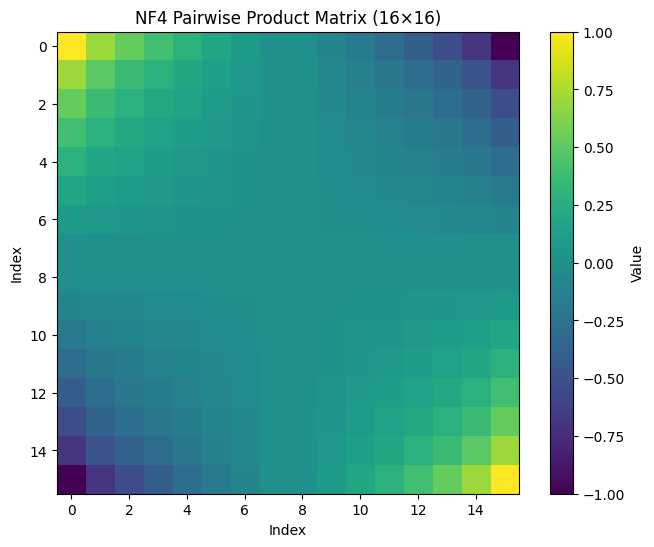

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C = np.array([-1.0000, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911, -0.0,
               0.0, 0.0911, 0.1848, 0.2844, 0.3949, 0.5251, 0.6962, 1.0000])

products = np.outer(C, C)
df = pd.DataFrame(products, columns=[f"C{i}" for i in range(len(C))], index=[f"C{i}" for i in range(len(C))])

print(df)

plt.figure(figsize=(8,6))
plt.imshow(products, aspect='equal')
plt.colorbar(label="Value")
plt.title("NF4 Pairwise Product Matrix (16×16)")
plt.xlabel("Index")
plt.ylabel("Index")
plt.show()


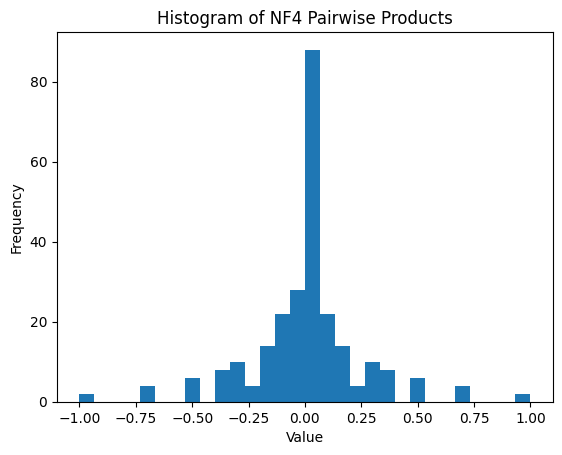

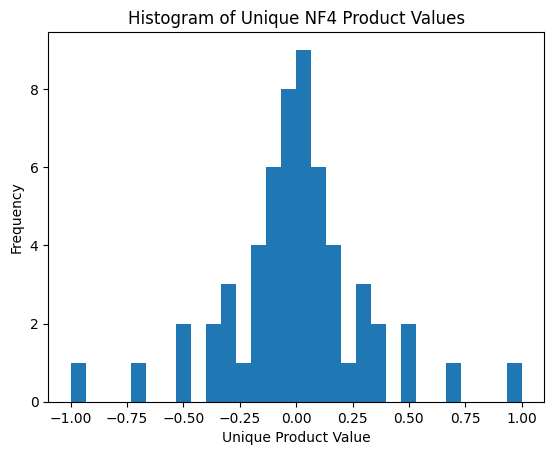

(57,)  unique values
(28,)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

C = np.array([-1.0000, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911, -0.0,
               0.0, 0.0911, 0.1848, 0.2844, 0.3949, 0.5251, 0.6962, 1.0000])

products = np.outer(C, C).flatten()

plt.figure()
plt.hist(products, bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of NF4 Pairwise Products")
plt.show()


unique_vals = np.unique(products)
unique_vals_pos = np.where(unique_vals > 0)
plt.figure()
plt.hist(unique_vals, bins=30)
plt.xlabel("Unique Product Value")
plt.ylabel("Frequency")
plt.title("Histogram of Unique NF4 Product Values")
plt.show()

print(unique_vals.shape, " unique values")
print(unique_vals_pos[0].shape)



1. Optimize bitwidth for keeping computational accuracy

In [7]:
vals = unique_vals[unique_vals_pos]
length = unique_vals_pos[0].shape[0]
LUT_5b_acc = {}
for i in range(0,length):
  binval = bin(i)
  #print(binval[2:].zfill(5), "-->", vals[i])
  LUT_5b_acc[binval[2:].zfill(5)] = vals[i]


2. Optimize bitwidth considering that the output is also a NF4.
- we generate a new codebook using Max-Lloyd quantization that fits the multiplications of NF4*NF4

In [8]:
import scipy.stats as stats

vals = products # unique_vals
mean = vals.mean()
std = vals.std()
phi_inv_16 = np.array([stats.norm.ppf(k/16) for k in range(1, 16)])
codebook_mult = mean + std*phi_inv_16
print(codebook_mult)

LUT_3b_norm = {}
for i in range(0,2**3):
  binval = bin(i)
  LUT_3b_norm[binval[2:].zfill(3)] = codebook_mult[i+7]

print(LUT_3b_norm)

[-0.39114399 -0.29329654 -0.22618956 -0.17196994 -0.1246199  -0.08124125
 -0.04010841  0.          0.04010841  0.08124125  0.1246199   0.17196994
  0.22618956  0.29329654  0.39114399]
{'000': 0.0, '001': 0.040108405456731444, '010': 0.08124125094254342, '011': 0.12461990438382307, '100': 0.1719699360810289, '101': 0.22618955588966205, '110': 0.29329653913436515, '111': 0.391143989773313}


3- Optimize bitwidth considering Lloyd-max quantization (same codebook as the weights)

Max-Lloyd quantization in the multiplication output distribution

In [9]:
import numpy as np

def lloyd_max_empirical(samples, K=16, max_iters=100, tol=1e-6):
    """
    Empirical Lloyd–Max quantizer for sampled data.

    Args:
        samples : 1D numpy array of samples
        K       : number of quantization levels
    Returns:
        c       : reconstruction levels
        b       : decision boundaries
    """

    samples = np.asarray(samples)
    samples = np.sort(samples)

    # Initialize centroids using quantiles (important!)
    c = np.quantile(samples, np.linspace(0, 1, K))

    for _ in range(max_iters):
        c_old = c.copy()

        # Decision boundaries
        b = np.zeros(K + 1)
        b[0] = -np.inf
        b[-1] = np.inf
        b[1:-1] = 0.5 * (c[:-1] + c[1:])

        # Assign samples to bins
        indices = np.digitize(samples, b) - 1

        # Update centroids
        for i in range(K):
            assigned = samples[indices == i]
            if len(assigned) > 0:
                c[i] = assigned.mean()

        # Convergence check
        if np.max(np.abs(c - c_old)) < tol:
            break

    return c, b


In [10]:
bits= 3

c, b = lloyd_max_empirical(products, K=2*2**bits)

# Normalize codebook to [-1, 1]
c = c / np.max(np.abs(c))
codebook = np.round(c, 4)

print(codebook)

LUT_3b_lmq = {}
for i in range(0,2**bits):
  LUT_3b_lmq[i] = codebook[i+2**bits]

print(LUT_3b_lmq)

[-1.000e+00 -5.474e-01 -2.935e-01 -1.678e-01 -1.017e-01 -5.500e-02
 -2.680e-02 -1.040e-02  3.000e-04  2.680e-02  5.500e-02  1.017e-01
  1.678e-01  2.935e-01  5.474e-01  1.000e+00]
{0: 0.0003, 1: 0.0268, 2: 0.055, 3: 0.1017, 4: 0.1678, 5: 0.2935, 6: 0.5474, 7: 1.0}


In [13]:
import numpy as np

def closest_value(x, arr): #TODO maybe rounding to the closest is not enough
    keys = list(arr.keys())
    values = np.array([arr[k] for k in keys])
    idx = np.argmin(np.abs(values - x))
    return values[idx]


NF4_MAG = np.array([-1.0000, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911, -0.0,
               0.0, 0.0911, 0.1848, 0.2844, 0.3949, 0.5251, 0.6962, 1.0000])

def build_nf4_mul_lut(magnitudes, LUT):
    lut = {}
    for i in range(8):
        for j in range(8):
            key = (i << 3) | j   # 6-bit key
            lut[key] = closest_value(magnitudes[i] * magnitudes[j], LUT)
    return lut

NF4_MUL_LUT = build_nf4_mul_lut(NF4_MAG[8:], LUT_3b_lmq)

def nf4_array_multiply(a, b, lut):
    """
    Elementwise NF4 × NF4 multiplication using LUT.

    a, b : np.ndarray of dtype np.uint8
           bit layout: [sign | idx2 idx1 idx0]
    lut  : dict mapping 6-bit key -> magnitude product
    """

    a = np.asarray(a, dtype=np.uint8)
    b = np.asarray(b, dtype=np.uint8)

    # Extract sign bit (0 or 1)
    sign_a = (a >> 3) & 0b1
    sign_b = (b >> 3) & 0b1

    # Extract 3-bit magnitude indices
    idx_a = a & 0b111
    idx_b = b & 0b111

    # XOR for output sign
    out_sign = sign_a ^ sign_b

    # Build 6-bit LUT keys
    keys = (idx_a << 3) | idx_b

    # Vectorized LUT lookup
    mag_prod = np.vectorize(lut.get)(keys)

    # Apply sign
    #result = np.bitwise_or(out_sign << 3, mag_prod)
    result = np.where(out_sign, -mag_prod,  mag_prod)

    return result

import numpy as np

vals4b = np.arange(16, dtype=np.uint8)
a = np.repeat(vals4b, 16)
b = np.tile(vals4b, 16)

c = nf4_array_multiply(a, b, NF4_MUL_LUT)

print(c)



[ 3.000e-04  3.000e-04  3.000e-04  3.000e-04  3.000e-04  3.000e-04
  3.000e-04  3.000e-04 -3.000e-04 -3.000e-04 -3.000e-04 -3.000e-04
 -3.000e-04 -3.000e-04 -3.000e-04 -3.000e-04  3.000e-04  3.000e-04
  2.680e-02  2.680e-02  2.680e-02  5.500e-02  5.500e-02  1.017e-01
 -3.000e-04 -3.000e-04 -2.680e-02 -2.680e-02 -2.680e-02 -5.500e-02
 -5.500e-02 -1.017e-01  3.000e-04  2.680e-02  2.680e-02  5.500e-02
  5.500e-02  1.017e-01  1.017e-01  1.678e-01 -3.000e-04 -2.680e-02
 -2.680e-02 -5.500e-02 -5.500e-02 -1.017e-01 -1.017e-01 -1.678e-01
  3.000e-04  2.680e-02  5.500e-02  1.017e-01  1.017e-01  1.678e-01
  1.678e-01  2.935e-01 -3.000e-04 -2.680e-02 -5.500e-02 -1.017e-01
 -1.017e-01 -1.678e-01 -1.678e-01 -2.935e-01  3.000e-04  2.680e-02
  5.500e-02  1.017e-01  1.678e-01  1.678e-01  2.935e-01  2.935e-01
 -3.000e-04 -2.680e-02 -5.500e-02 -1.017e-01 -1.678e-01 -1.678e-01
 -2.935e-01 -2.935e-01  3.000e-04  5.500e-02  1.017e-01  1.678e-01
  1.678e-01  2.935e-01  2.935e-01  5.474e-01 -3.000e-04 -5.500

4. accumulator bitwidth sizing